# FactoryMind AI — Official FD001 Endpoint Evaluation

This notebook performs the first official endpoint evaluation of the frozen RUL methodology selected in notebook 08. The official labels are used only after the feature contract, target cap, preprocessing, model families, and hyperparameters have been fixed.

After this analysis, FD001's official test set is **development-exposed** and must not be described as an untouched production validation set.

## 1. Load and Validate Train, Test, and Endpoint Labels

Training trajectories run to failure. Test trajectories stop before failure, and `RUL_FD001.txt` supplies one remaining-life value after the final observed cycle for each ordered test unit.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 5), "axes.titlesize": 13, "axes.labelsize": 11})
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

DATA_DIR = Path("../data/raw")
if not DATA_DIR.exists():
    DATA_DIR = Path("data/raw")
TRAIN_PATH = DATA_DIR / "train_FD001.txt"
TEST_PATH = DATA_DIR / "test_FD001.txt"
RUL_PATH = DATA_DIR / "RUL_FD001.txt"
for path in (TRAIN_PATH, TEST_PATH, RUL_PATH):
    assert path.exists(), f"Missing required file: {path}"

columns = (["unit_id", "cycle"]
           + [f"operational_setting_{i}" for i in range(1, 4)]
           + [f"sensor_{i}" for i in range(1, 22)])
train = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None, names=columns)
test = pd.read_csv(TEST_PATH, sep=r"\s+", header=None, names=columns)
official_labels = pd.read_csv(RUL_PATH, sep=r"\s+", header=None, names=["official_raw_RUL"])

assert train.shape == (20_631, 26)
assert train["unit_id"].nunique() == 100
assert test.shape == (13_096, 26)
assert test["unit_id"].nunique() == 100
assert len(official_labels) == 100
assert list(np.sort(test["unit_id"].unique())) == list(range(1, 101))

print(f"Train: {train.shape}, {train['unit_id'].nunique()} units")
print(f"Test: {test.shape}, {test['unit_id'].nunique()} units")
print(f"Official endpoint labels: {len(official_labels)}")

Train: (20631, 26), 100 units
Test: (13096, 26), 100 units
Official endpoint labels: 100


## 2. Recreate the Frozen Training Methodology

No features are added or removed here. Temporal features use positive lags and trailing windows grouped by unit. Labels do not participate in feature construction.

In [2]:
RUL_CAP = 125
train["raw_rul"] = train.groupby("unit_id")["cycle"].transform("max") - train["cycle"]
train["capped_rul"] = train["raw_rul"].clip(upper=RUL_CAP)

constant_sensors = ["sensor_1", "sensor_5", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]
near_constant_excluded = ["sensor_6"]
retained_sensors = [f"sensor_{i}" for i in range(1, 22)
                    if f"sensor_{i}" not in constant_sensors + near_constant_excluded]
temporal_base_sensors = ["sensor_4", "sensor_7", "sensor_11", "sensor_12", "sensor_15", "sensor_21"]
raw_predictors = ["cycle", "operational_setting_1", "operational_setting_2"] + retained_sensors

def add_frozen_temporal_features(frame):
    result = frame.sort_values(["unit_id", "cycle"]).copy()
    grouped = result.groupby("unit_id", sort=False)
    engineered = []
    for sensor in temporal_base_sensors:
        lag_1 = f"{sensor}_lag_1"
        lag_5 = f"{sensor}_lag_5"
        rolling_mean = f"{sensor}_rolling_mean_5"
        rolling_std = f"{sensor}_rolling_std_5"
        delta_1 = f"{sensor}_delta_1"
        result[lag_1] = grouped[sensor].shift(1)
        result[lag_5] = grouped[sensor].shift(5)
        result[rolling_mean] = grouped[sensor].transform(
            lambda values: values.rolling(5, min_periods=1).mean()
        )
        result[rolling_std] = grouped[sensor].transform(
            lambda values: values.rolling(5, min_periods=1).std(ddof=0)
        )
        result[delta_1] = result[sensor] - result[lag_1]
        engineered.extend([lag_1, lag_5, rolling_mean, rolling_std, delta_1])
    return result, engineered

train_features, engineered_predictors = add_frozen_temporal_features(train)
test_features, test_engineered_predictors = add_frozen_temporal_features(test)
proposed_predictors = raw_predictors + engineered_predictors

assert engineered_predictors == test_engineered_predictors
assert len(raw_predictors) == 17
assert len(engineered_predictors) == 30
assert len(proposed_predictors) == 47
assert not {"unit_id", "raw_rul", "capped_rul"}.intersection(proposed_predictors)
assert not set(constant_sensors + near_constant_excluded).intersection(proposed_predictors)
assert (train_features["capped_rul"] <= RUL_CAP).all()
assert train_features.groupby("unit_id").head(1)[[f"{s}_lag_1" for s in temporal_base_sensors]].isna().all().all()
assert test_features.groupby("unit_id").head(1)[[f"{s}_lag_1" for s in temporal_base_sensors]].isna().all().all()

print(f"Frozen contract recreated: {len(raw_predictors)} raw + {len(engineered_predictors)} temporal = {len(proposed_predictors)} predictors")

Frozen contract recreated: 17 raw + 30 temporal = 47 predictors


## 3. Fit the Frozen Development Candidates

Both pipelines use median imputation with missing indicators. The configurations exactly match notebook 08. They are fitted once on all training observations; no official test label is used during fitting or preprocessing.

In [3]:
def make_preprocessor(feature_names):
    return ColumnTransformer([
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ]), feature_names)
    ], remainder="drop")

frozen_models = {
    "Random Forest": Pipeline([
        ("preprocess", make_preprocessor(proposed_predictors)),
        ("model", RandomForestRegressor(
            n_estimators=200, max_features=0.7, min_samples_leaf=3,
            random_state=42, n_jobs=-1,
        )),
    ]),
    "HistGradientBoosting": Pipeline([
        ("preprocess", make_preprocessor(proposed_predictors)),
        ("model", HistGradientBoostingRegressor(
            learning_rate=0.07, max_iter=250, max_leaf_nodes=31,
            min_samples_leaf=20, l2_regularization=0.1, random_state=42,
        )),
    ]),
}

X_train = train_features[proposed_predictors]
y_train = train_features["capped_rul"]
fitted_models = {}
for name, model in frozen_models.items():
    fitted_models[name] = clone(model).fit(X_train, y_train)
    print(f"Fitted frozen {name} on {len(X_train):,} training observations.")

Fitted frozen Random Forest on 20,631 training observations.


Fitted frozen HistGradientBoosting on 20,631 training observations.


## 4. Construct One Test Endpoint per Engine

The complete observed trajectory is needed to compute causal lag and rolling features. Evaluation then selects only the maximum observed cycle for each test unit. The endpoint label is never merged into cycle-level feature engineering.

In [4]:
endpoint_indices = test_features.groupby("unit_id")["cycle"].idxmax()
test_endpoints = test_features.loc[endpoint_indices].sort_values("unit_id").reset_index(drop=True)
assert len(test_endpoints) == 100
assert test_endpoints["unit_id"].nunique() == 100
assert test_endpoints["unit_id"].is_unique
assert test_endpoints["unit_id"].tolist() == list(range(1, 101))

endpoint_targets = pd.DataFrame({
    "unit_id": test_endpoints["unit_id"].to_numpy(),
    "official_raw_RUL": official_labels["official_raw_RUL"].astype(int).to_numpy(),
})
endpoint_targets["official_capped_RUL"] = endpoint_targets["official_raw_RUL"].clip(upper=RUL_CAP)

# Alignment is positional by the documented ordered test-unit convention.
assert len(endpoint_targets) == test["unit_id"].nunique() == len(official_labels)
assert endpoint_targets["unit_id"].tolist() == sorted(test["unit_id"].unique().tolist())
assert (test_endpoints["cycle"].to_numpy() == test.groupby("unit_id")["cycle"].max().sort_index().to_numpy()).all()

X_endpoint = test_endpoints[proposed_predictors]
predictions_by_model = {
    name: model.predict(X_endpoint) for name, model in fitted_models.items()
}
assert all(len(predictions) == 100 for predictions in predictions_by_model.values())
print("Endpoint matrix:", X_endpoint.shape)
display(endpoint_targets.head())

Endpoint matrix: (100, 47)


,unit_id,official_raw_RUL,official_capped_RUL
0,1,112,112
1,2,98,98
2,3,69,69
3,4,82,82
4,5,91,91


## 5. Metrics and Prediction Table

Because the model learned capped RUL, capped endpoint metrics are the directly aligned evaluation. Raw-label metrics are reported for context and expose the unavoidable mismatch for official RUL values above 125.

The NASA penalty uses \(d=\hat{y}-y\), with \(\exp(-d/13)-1\) for early predictions and \(\exp(d/10)-1\) for late predictions. Positive error overestimates remaining life and is penalized more steeply. The table reports both the traditional total score and mean penalty per engine.

In [5]:
def nasa_scores(y_true, y_pred):
    error = np.asarray(y_pred) - np.asarray(y_true)
    penalty = np.where(error < 0, np.exp(-error / 13.0) - 1, np.exp(error / 10.0) - 1)
    return float(penalty.sum()), float(penalty.mean())

def endpoint_metrics(y_true, y_pred):
    nasa_total, nasa_mean = nasa_scores(y_true, y_pred)
    return {
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "NASA_total_score": nasa_total,
        "NASA_mean_penalty": nasa_mean,
    }

results = endpoint_targets.copy()
results["last_observed_cycle"] = test_endpoints["cycle"].to_numpy()
for name, predictions in predictions_by_model.items():
    prefix = "rf" if name == "Random Forest" else "hgb"
    results[f"{prefix}_predicted_RUL"] = predictions
    results[f"{prefix}_raw_error"] = predictions - results["official_raw_RUL"]
    results[f"{prefix}_capped_error"] = predictions - results["official_capped_RUL"]
    results[f"{prefix}_absolute_error"] = results[f"{prefix}_capped_error"].abs()

rf_capped_metrics = endpoint_metrics(results["official_capped_RUL"], results["rf_predicted_RUL"])
rf_raw_metrics = endpoint_metrics(results["official_raw_RUL"], results["rf_predicted_RUL"])
print("Random Forest — capped endpoint target")
display(pd.Series(rf_capped_metrics).to_frame("value"))
print("Random Forest — raw endpoint target")
display(pd.Series(rf_raw_metrics).to_frame("value"))

prediction_table = results[[
    "unit_id", "last_observed_cycle", "official_raw_RUL", "official_capped_RUL",
    "rf_predicted_RUL", "rf_raw_error", "rf_capped_error", "rf_absolute_error",
]].copy()
assert len(prediction_table) == 100
print("Best capped-target predictions")
display(prediction_table.nsmallest(8, "rf_absolute_error"))
print("Worst capped-target predictions")
display(prediction_table.nlargest(8, "rf_absolute_error"))
print("Largest RUL overestimates")
display(prediction_table.nlargest(8, "rf_raw_error"))
print("Largest RUL underestimates")
display(prediction_table.nsmallest(8, "rf_raw_error"))

Random Forest — capped endpoint target


,value
RMSE,17.5413
MAE,13.0300
R2,0.8084
NASA_total_score,522.9481
NASA_mean_penalty,5.2295


Random Forest — raw endpoint target


,value
RMSE,18.7613
MAE,14.1000
R2,0.7962
NASA_total_score,583.9347
NASA_mean_penalty,5.8393


Best capped-target predictions


...

,unit_id,last_observed_cycle,official_raw_RUL,official_capped_RUL,rf_predicted_RUL,rf_raw_error,rf_capped_error,rf_absolute_error
44,45,152,114,114,62.7267,-51.2733,-51.2733,51.2733
73,74,137,126,125,76.3581,-49.6419,-48.6419,48.6419
29,30,143,115,115,72.9052,-42.0948,-42.0948,42.0948
17,18,133,28,28,66.5666,38.5666,38.5666,38.5666
36,37,121,21,21,59.2806,38.2806,38.2806,38.2806
92,93,244,85,85,48.1093,-36.8907,-36.8907,36.8907
88,89,177,136,125,90.5344,-45.4656,-34.4656,34.4656
78,79,101,63,63,96.9550,33.9550,33.9550,33.9550


Largest RUL overestimates


,unit_id,last_observed_cycle,official_raw_RUL,official_capped_RUL,rf_predicted_RUL,rf_raw_error,rf_capped_error,rf_absolute_error
17,18,133,28,28,66.5666,38.5666,38.5666,38.5666
36,37,121,21,21,59.2806,38.2806,38.2806,38.2806
78,79,101,63,63,96.9550,33.9550,33.9550,33.9550
14,15,76,83,83,114.5574,31.5574,31.5574,31.5574
66,67,71,77,77,107.7560,30.7560,30.7560,30.7560
26,27,140,66,66,95.8943,29.8943,29.8943,29.8943
40,41,123,18,18,47.0379,29.0379,29.0379,29.0379
1,2,49,98,98,121.6801,23.6801,23.6801,23.6801


Largest RUL underestimates


,unit_id,last_observed_cycle,official_raw_RUL,official_capped_RUL,rf_predicted_RUL,rf_raw_error,rf_capped_error,rf_absolute_error
44,45,152,114,114,62.7267,-51.2733,-51.2733,51.2733
73,74,137,126,125,76.3581,-49.6419,-48.6419,48.6419
88,89,177,136,125,90.5344,-45.4656,-34.4656,34.4656
29,30,143,115,115,72.9052,-42.0948,-42.0948,42.0948
54,55,113,137,125,96.1462,-40.8538,-28.8538,28.8538
92,93,244,85,85,48.1093,-36.8907,-36.8907,36.8907
46,47,73,135,125,104.6367,-30.3633,-20.3633,20.3633
56,57,160,103,103,73.7661,-29.2339,-29.2339,29.2339


## 6. Operationally Important Overestimation

An overestimate means the model predicts more usable cycles than the official endpoint label. These are development-stage model errors, not observed safety incidents.

In [6]:
def error_band_table(predictions):
    frame = endpoint_targets.copy()
    frame["prediction"] = predictions
    frame["signed_error"] = frame["prediction"] - frame["official_raw_RUL"]
    frame["rul_band"] = pd.cut(
        frame["official_raw_RUL"], [-np.inf, 30, 80, np.inf],
        labels=["Near failure (0–30)", "Mid-life (31–80)", "Healthy/early (>80)"]
    )
    bands = frame.groupby("rul_band", observed=True).apply(
        lambda group: pd.Series({
            "count": len(group),
            "RMSE": mean_squared_error(group["official_raw_RUL"], group["prediction"]) ** 0.5,
            "MAE": mean_absolute_error(group["official_raw_RUL"], group["prediction"]),
            "mean_signed_error": group["signed_error"].mean(),
        }), include_groups=False
    )
    return frame, bands

rf_error_frame, rf_band_metrics = error_band_table(predictions_by_model["Random Forest"])
near_failure_rf = rf_error_frame.loc[rf_error_frame["official_raw_RUL"] <= 30]

overestimation_counts = pd.Series({
    "all_units_overestimate_gt_5": int((rf_error_frame["signed_error"] > 5).sum()),
    "all_units_overestimate_gt_10": int((rf_error_frame["signed_error"] > 10).sum()),
    "all_units_overestimate_gt_20": int((rf_error_frame["signed_error"] > 20).sum()),
    "near_failure_units": len(near_failure_rf),
    "near_failure_overestimate_gt_5": int((near_failure_rf["signed_error"] > 5).sum()),
    "near_failure_overestimate_gt_10": int((near_failure_rf["signed_error"] > 10).sum()),
    "near_failure_overestimate_gt_20": int((near_failure_rf["signed_error"] > 20).sum()),
})
display(overestimation_counts.to_frame("count"))
display(rf_band_metrics)

,count
all_units_overestimate_gt_5,39
all_units_overestimate_gt_10,26
all_units_overestimate_gt_20,11
near_failure_units,25
near_failure_overestimate_gt_5,10
near_failure_overestimate_gt_10,7
near_failure_overestimate_gt_20,4


,count,RMSE,MAE,mean_signed_error
rul_band,,,,
Near failure (0–30),25.0000,14.1842,8.8359,7.0016
Mid-life (31–80),20.0000,17.1742,14.3326,6.5164
Healthy/early (>80),55.0000,21.0064,16.4083,-7.3345


Notebook 08's unit-held-out OOF analysis also found positive mean error near failure. Agreement in direction is important: endpoint evaluation can quantify the behavior but should not be used to tune it away in this notebook.

## 7. Endpoint Visualizations

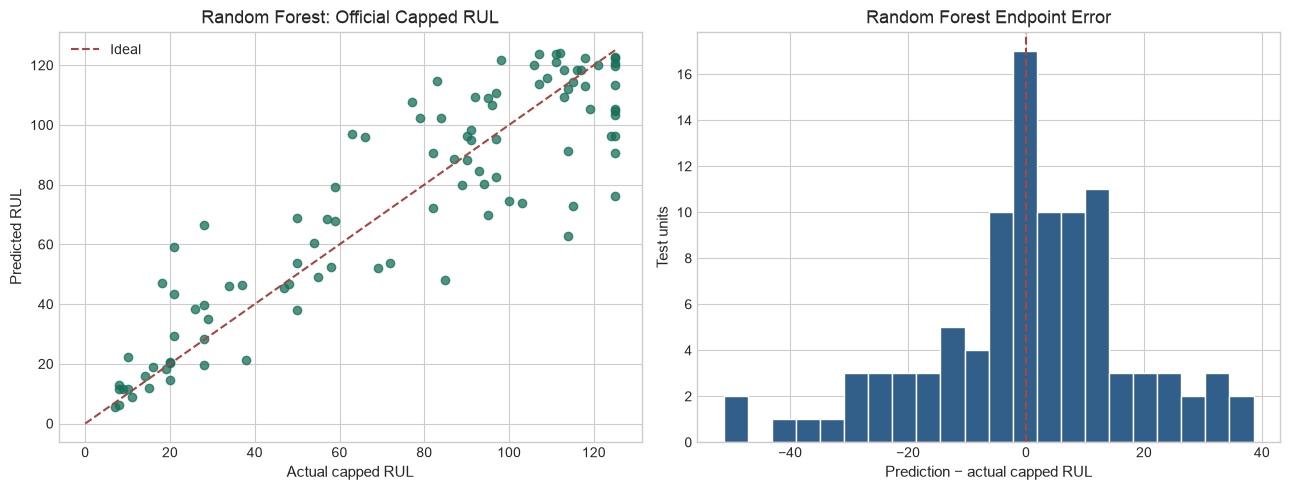

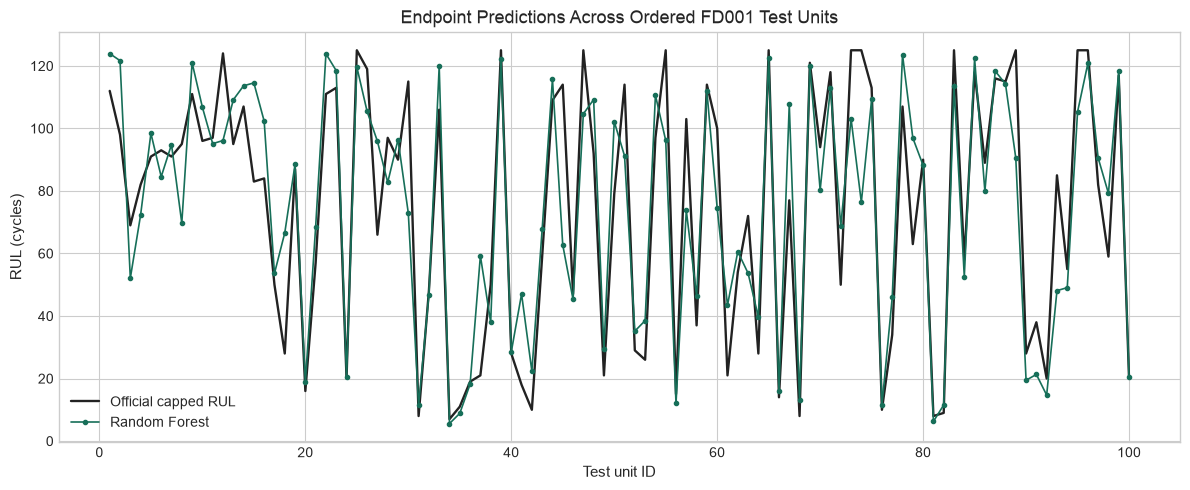

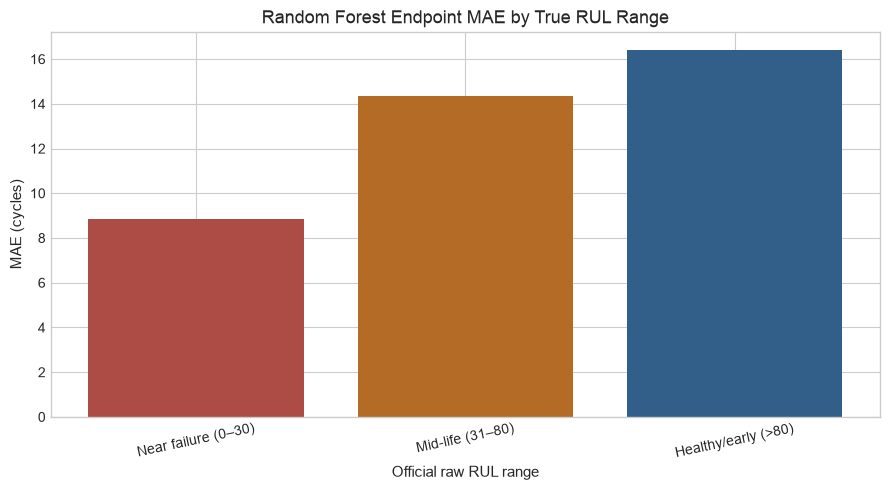

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(results["official_capped_RUL"], results["rf_predicted_RUL"], color="#176f59", alpha=0.75)
axes[0].plot([0, RUL_CAP], [0, RUL_CAP], "--", color="#a74641", label="Ideal")
axes[0].set(title="Random Forest: Official Capped RUL", xlabel="Actual capped RUL", ylabel="Predicted RUL")
axes[0].legend()
axes[1].hist(results["rf_capped_error"], bins=22, color="#315f8a", edgecolor="white")
axes[1].axvline(0, color="#a74641", linestyle="--")
axes[1].set(title="Random Forest Endpoint Error", xlabel="Prediction − actual capped RUL", ylabel="Test units")
plt.tight_layout()
plt.show()

ordered = results.sort_values("unit_id")
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ordered["unit_id"], ordered["official_capped_RUL"], color="#222222", linewidth=1.7, label="Official capped RUL")
ax.plot(ordered["unit_id"], ordered["rf_predicted_RUL"], color="#176f59", linewidth=1.2, marker="o", markersize=3, label="Random Forest")
ax.set(title="Endpoint Predictions Across Ordered FD001 Test Units", xlabel="Test unit ID", ylabel="RUL (cycles)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
plot_bands = rf_band_metrics.reset_index()
ax.bar(plot_bands["rul_band"].astype(str), plot_bands["MAE"], color=["#ad4b45", "#b36b25", "#315f8a"])
ax.set(title="Random Forest Endpoint MAE by True RUL Range", xlabel="Official raw RUL range", ylabel="MAE (cycles)")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

## 8. Frozen Candidate Comparison

Random Forest and Histogram Gradient Boosting were preselected before official-label access. Both are evaluated once using their unchanged notebook 08 configurations. This is a bounded final development comparison, not open-ended test-driven model shopping.

In [8]:
comparison_rows = []
model_band_metrics = {}
for name, predictions in predictions_by_model.items():
    capped_metrics = endpoint_metrics(endpoint_targets["official_capped_RUL"], predictions)
    error_frame, band_metrics = error_band_table(predictions)
    model_band_metrics[name] = band_metrics
    near = band_metrics.loc["Near failure (0–30)"]
    comparison_rows.append({
        "Model": name,
        "capped_RMSE": capped_metrics["RMSE"],
        "capped_MAE": capped_metrics["MAE"],
        "capped_R2": capped_metrics["R2"],
        "NASA_total_score": capped_metrics["NASA_total_score"],
        "NASA_mean_penalty": capped_metrics["NASA_mean_penalty"],
        "near_failure_RMSE": near["RMSE"],
        "near_failure_MAE": near["MAE"],
        "near_failure_mean_error": near["mean_signed_error"],
        "overestimates_gt_20": int((error_frame["signed_error"] > 20).sum()),
    })
model_comparison = pd.DataFrame(comparison_rows).set_index("Model")
display(model_comparison)

# Multi-criterion rank prevents a decision based on one tiny metric difference.
decision_columns = [
    "capped_RMSE", "capped_MAE", "NASA_mean_penalty",
    "near_failure_RMSE", "near_failure_MAE", "overestimates_gt_20",
]
model_comparison["mean_decision_rank"] = model_comparison[decision_columns].rank(method="average").mean(axis=1)
selected_model = model_comparison["mean_decision_rank"].idxmin()
print("Multi-criterion provisional candidate:", selected_model)

,capped_RMSE,capped_MAE,capped_R2,NASA_total_score,NASA_mean_penalty,near_failure_RMSE,near_failure_MAE,near_failure_mean_error,overestimates_gt_20
Model,,,,,,,,,
Random Forest,17.5413,13.0300,0.8084,522.9481,5.2295,14.1842,8.8359,7.0016,11
HistGradientBoosting,18.1886,13.4048,0.7940,568.4132,5.6841,13.9985,8.7492,6.4721,12


Multi-criterion provisional candidate: Random Forest


## 9. Representative Endpoint Examples

Examples are selected by explicit rules: minimum true RUL, closest to median true RUL, maximum true RUL, smallest absolute error, and largest absolute error. Duplicate units are removed. This supports interpretation without presenting cherry-picked examples as global evidence.

In [9]:
selected_prefix = "rf" if selected_model == "Random Forest" else "hgb"
example_source = results.copy()
example_source["selected_prediction"] = example_source[f"{selected_prefix}_predicted_RUL"]
example_source["selected_signed_error"] = example_source["selected_prediction"] - example_source["official_raw_RUL"]
example_source["selected_absolute_error"] = example_source["selected_signed_error"].abs()
median_rul = example_source["official_raw_RUL"].median()
example_indices = [
    example_source["official_raw_RUL"].idxmin(),
    (example_source["official_raw_RUL"] - median_rul).abs().idxmin(),
    example_source["official_raw_RUL"].idxmax(),
    example_source["selected_absolute_error"].idxmin(),
    example_source["selected_absolute_error"].idxmax(),
]
selection_labels = ["low true RUL", "mid-range true RUL", "high true RUL", "strong prediction", "poor prediction"]
examples = example_source.loc[example_indices, [
    "unit_id", "last_observed_cycle", "official_raw_RUL",
    "selected_prediction", "selected_signed_error", "selected_absolute_error",
]].copy()
examples.insert(0, "selection_reason", selection_labels)
examples = examples.drop_duplicates("unit_id", keep="first")
display(examples)

,selection_reason,unit_id,last_observed_cycle,official_raw_RUL,selected_prediction,selected_signed_error,selected_absolute_error
33,low true RUL,34,203,7,5.5955,-1.4045,1.4045
18,mid-range true RUL,19,135,87,88.5465,1.5465,1.5465
24,high true RUL,25,48,145,119.6560,-25.3440,25.3440
23,strong prediction,24,186,20,20.3801,0.3801,0.3801
44,poor prediction,45,152,114,62.7267,-51.2733,51.2733


## 10. Model-Family Decision and Caveats

The multi-criterion decision weighs capped endpoint accuracy, asymmetric penalty, near-failure error, and large overestimation—not a single small RMSE difference. Computational practicality and consistency with GroupKFold remain qualitative considerations.

Methodological limitations:

- FD001 is simulated and contains one operating condition and one fault mode.
- Only 100 official test engines are available.
- The 125-cycle cap is provisional and truncates long-horizon distinctions.
- This official test set is now development-exposed.
- There is no external real-fleet validation.
- The models provide point estimates without uncertainty intervals.
- Predictions must not be interpreted as guaranteed remaining life or autonomous maintenance decisions.

## 11. Validation

In [10]:
assert len(results) == 100
assert results["unit_id"].nunique() == 100
assert results["unit_id"].is_unique
assert endpoint_targets["unit_id"].tolist() == list(range(1, 101))
assert all(np.isfinite(predictions).all() for predictions in predictions_by_model.values())
assert not {"unit_id", "raw_rul", "capped_rul"}.intersection(proposed_predictors)

labels_used_in_feature_engineering = False
hyperparameter_tuning_performed = False
production_artifact_created = False
new_model_family_added_after_test_access = False
assert not labels_used_in_feature_engineering
assert not hyperparameter_tuning_performed
assert not production_artifact_created
assert not new_model_family_added_after_test_access

validation = pd.Series({
    "exactly_100_endpoint_rows": len(results) == 100,
    "each_test_unit_appears_once": results["unit_id"].is_unique,
    "official_labels_align_with_ordered_units": endpoint_targets["unit_id"].tolist() == list(range(1, 101)),
    "all_predictions_finite": all(np.isfinite(p).all() for p in predictions_by_model.values()),
    "test_labels_entered_feature_engineering": labels_used_in_feature_engineering,
    "hyperparameter_tuning_performed": hyperparameter_tuning_performed,
    "production_artifact_created": production_artifact_created,
    "new_model_family_added_after_test_access": new_model_family_added_after_test_access,
})
display(validation.to_frame("result"))

,result
exactly_100_endpoint_rows,True
each_test_unit_appears_once,True
official_labels_align_with_ordered_units,True
all_predictions_finite,True
test_labels_entered_feature_engineering,False
hyperparameter_tuning_performed,False
production_artifact_created,False
new_model_family_added_after_test_access,False


## Official RUL Test Evaluation Conclusions

- **Random Forest, capped target:** RMSE 17.54, MAE 13.03, R² 0.808, NASA total score 522.95, and mean NASA penalty 5.23.
- **Random Forest, raw target:** RMSE 18.76, MAE 14.10, R² 0.796, NASA total score 583.93, and mean NASA penalty 5.84. Raw performance is weaker partly because the model was deliberately trained not to distinguish targets above 125 cycles.
- **Histogram Gradient Boosting, capped target:** RMSE 18.19, MAE 13.40, R² 0.794, NASA total score 568.41, and mean NASA penalty 5.68. It was slightly better near failure (RMSE 14.00 versus 14.18), but Random Forest was stronger on every overall capped endpoint metric.
- **Decision:** retain Random Forest. This does not change notebook 08's provisional family. The official endpoint advantage is meaningful but not large enough to imply broad superiority outside FD001.
- **Near failure:** among 25 units with 30 or fewer true cycles remaining, Random Forest achieved RMSE 14.18 and MAE 8.84, with mean signed error +7.00 cycles. It overestimated by more than 5 cycles for 10 units, more than 10 for 7 units, and more than 20 for 4 units.
- Across all 100 units, Random Forest overestimated by more than 5, 10, and 20 cycles for 39, 26, and 11 units respectively. These are development-stage errors, not observed safety incidents.
- The largest overestimates were units 18 and 37 at approximately +38.6 and +38.3 cycles. The largest capped-target underestimate was unit 45 at approximately -51.3 cycles. These tails prevent treating point estimates as guaranteed remaining life.
- The current system is suitable for a **guarded backend prototype** that clearly communicates development status and avoids autonomous maintenance decisions. It is not suitable for production operations without uncertainty estimates, external fleet validation, and controls for conservative near-failure decisions.
- The official test set is now development-exposed and can no longer serve as an untouched lockbox. FD001 remains simulated, single-condition, single-fault-mode data with only 100 endpoint engines.

**Recommended next step if results are acceptable:** create `notebooks/10_rul_model_finalization.ipynb` to freeze the chosen model specification, define uncertainty and output semantics, and prepare a reusable production pipeline. Notebook 10 is not created here.